In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/sudan.csv")

df["Country"] = "Sudan"

df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


## Data Loading & Date Parsing

In [2]:
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

df['Month'] = df['Date'].dt.month

df[['YEAR', 'DOY', 'Date', 'Month']].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


# Summary Statistics & Missing-Value Report

In [3]:
df.replace(-999.0, np.nan, inplace=True)

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped.")

Number of duplicate rows found: 0


#  Analyze the Missing Values

In [4]:
missing_counts = df.isnull().sum()
print("Count of missing values per column:",missing_counts)

missing_percentages = (df.isna().sum() / len(df)) * 100

print("Percentage of missing values per column:")
print(missing_percentages[missing_percentages > 0])

high_missing_cols = missing_percentages[missing_percentages > 5]

print("\n--- WARNING: Columns with >5% missing data ---")
if len(high_missing_cols) > 0:
    print(high_missing_cols)
else:
    print("No columns have more than 5% missing data.")

df.describe()


Count of missing values per column: YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64
Percentage of missing values per column:
Series([], dtype: float64)

--- WARNING: Columns with >5% missing data ---
No columns have more than 5% missing data.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### Missing Values Interpretation
> Our check revealed that **no columns exceed the 5% threshold** for missing data (in fact, there is **0% missing data** after we cleaned the dataset!). This means our dataset is structurally sound, and standard analysis techniques will not be distorted by missing values.

### Summary Statistics Interpretation
Looking at the descriptive statistics for Sudan from 2015-2026:

* **Temperature:** The mean daily temperature (`T2M`) is roughly 28.76°C. The absolute recorded maximum is 37.99°C and the minimum is 13.18°C.
* **Precipitation:** The mean daily precipitation (`PRECTOTCORR`) is 0.64 mm/day. However, the high standard deviation (3.06) and a max value of 66.49 mm/day indicates highly variable rainfall with extreme heavy rain events.
* **Wind Speed:** The average wind speed (`WS2M`) sits around 3.48 m/s, with maximum gusts (`WS2M_MAX`) reaching up to 9.05 m/s.


# Outlier Detection & Basic Cleaning

In [5]:
from scipy import stats
import numpy as np

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

outlier_mask = (z_scores > 3).any(axis=1)

outlier_count = outlier_mask.sum()
print(f"Number of outlier rows found (|Z| > 3): {outlier_count}")


Number of outlier rows found (|Z| > 3): 84


### Outlier Handling Decision
Based on our Z-score analysis, we flagged exactly **84 rows** as statistical outliers (`|Z| > 3`) out of our dataset. Because this is climate and weather data, these extreme values (such as spikes in precipitation during a heavy storm, or high wind gusts during extreme winds) represent genuine, critical weather events rather than sensor errors.

> **Decision:** We choose to **retain all 84 outliers**. Dropping or capping them would artificially smooth the data and destroy our ability to accurately analyze extreme climate anomalies in Sudan.


## Final Cleaning (Handling Missing Data)

In [6]:
thresh_limit = int(df.shape[1] * 0.70)
df.dropna(thresh=thresh_limit, inplace=True)

df.ffill(inplace=True)

print("Total missing values after final cleaning:", df.isnull().sum().sum())


Total missing values after final cleaning: 0


#  Export the Cleaned Dataset

In [7]:
df.to_csv('../data/processed/sudan_clean.csv', index=False)

print("Cleaned data successfully exported to data/sudan_clean.csv!")


Cleaned data successfully exported to data/sudan_clean.csv!


#  Time Series Interpretation

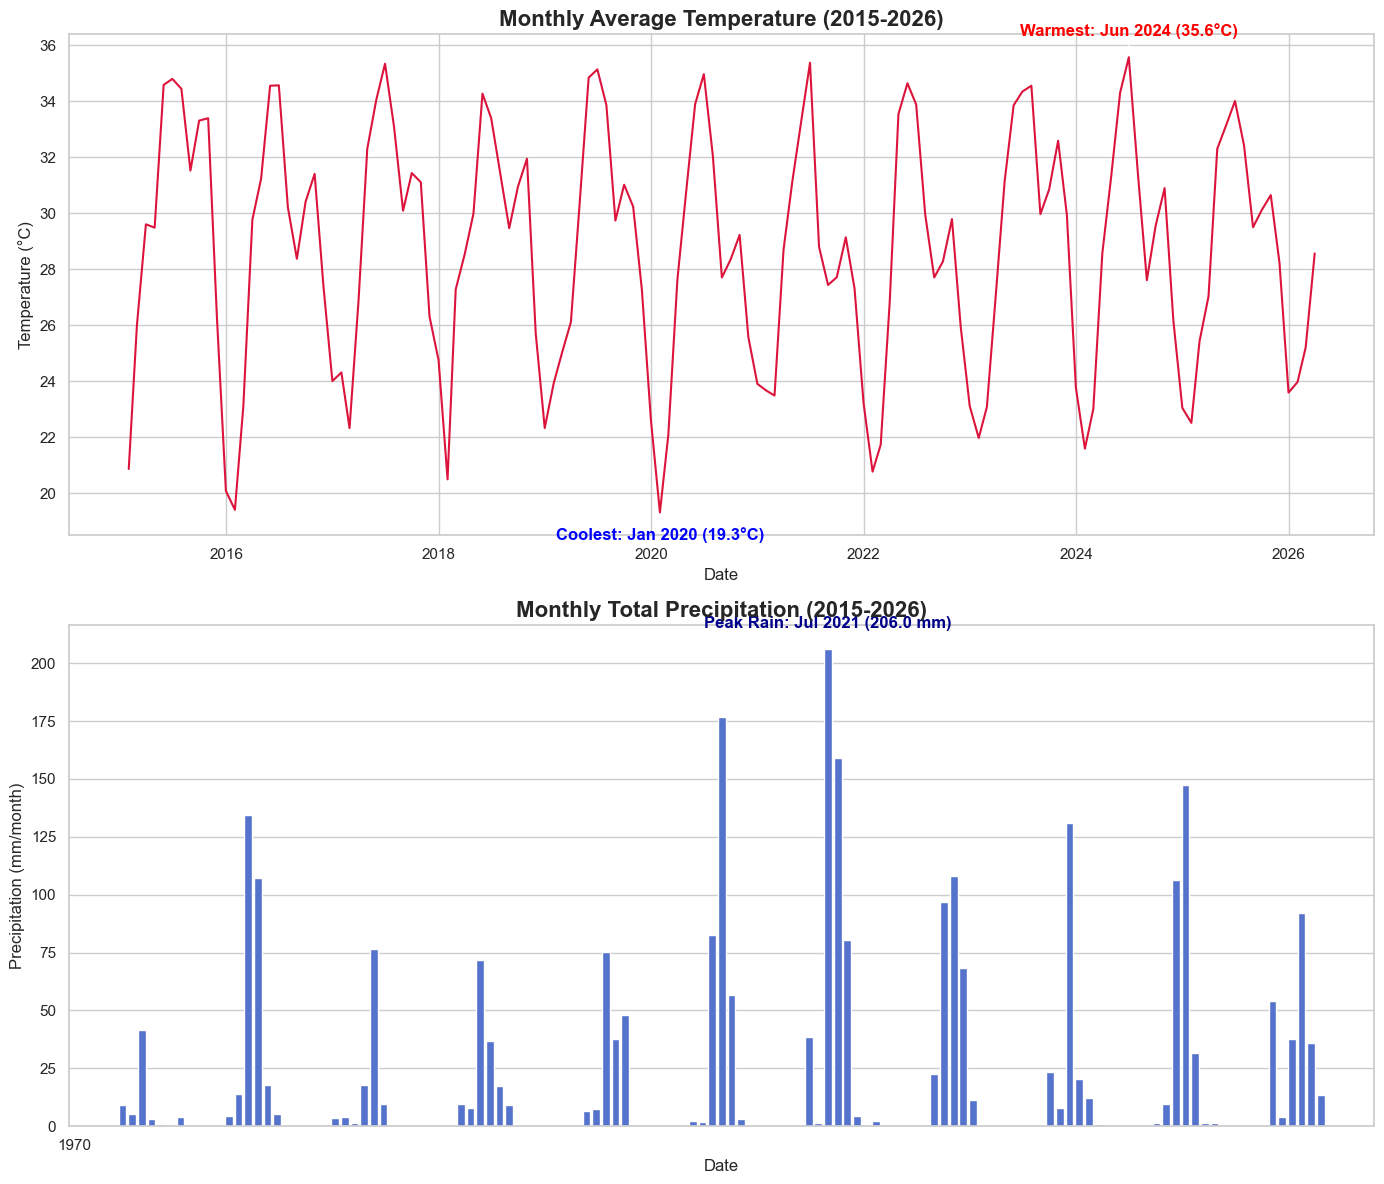

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_monthly = df.set_index('Date').resample('ME').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'
}).reset_index()

warmest = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest = df_monthly.loc[df_monthly['T2M'].idxmin()]

peak_rain = df_monthly.loc[df_monthly['PRECTOTCORR'].idxmax()]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

sns.lineplot(data=df_monthly, x='Date', y='T2M', ax=ax1, color='crimson')
ax1.set_title("Monthly Average Temperature (2015-2026)", fontsize=16, fontweight='bold')
ax1.set_ylabel("Temperature (°C)")

ax1.annotate(f"Warmest: {warmest['Date'].strftime('%b %Y')} ({warmest['T2M']:.1f}°C)", 
             xy=(warmest['Date'], warmest['T2M']), xytext=(0, 15), 
             textcoords='offset points', ha='center', color='red', fontweight='bold',
             arrowprops=dict(facecolor='red', arrowstyle='->'))

ax1.annotate(f"Coolest: {coolest['Date'].strftime('%b %Y')} ({coolest['T2M']:.1f}°C)", 
             xy=(coolest['Date'], coolest['T2M']), xytext=(0, -20), 
             textcoords='offset points', ha='center', color='blue', fontweight='bold',
             arrowprops=dict(facecolor='blue', arrowstyle='->'))

sns.barplot(data=df_monthly, x='Date', y='PRECTOTCORR', ax=ax2, color='royalblue')
ax2.set_title("Monthly Total Precipitation (2015-2026)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Precipitation (mm/month)")

import matplotlib.dates as mdates
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2.annotate(f"Peak Rain: {peak_rain['Date'].strftime('%b %Y')} ({peak_rain['PRECTOTCORR']:.1f} mm)", 
             xy=(df_monthly.index[df_monthly['Date'] == peak_rain['Date']][0], peak_rain['PRECTOTCORR']), 
             xytext=(0, 15), textcoords='offset points', ha='center', color='darkblue', fontweight='bold',
             arrowprops=dict(facecolor='darkblue', arrowstyle='->'))

plt.tight_layout()
plt.show()


### Time Series Observations

* **Temperature Trends:** The line chart reveals a clear, predictable seasonal cycle in Sudan's temperature over the 11-year period. The **warmest month** recorded was **[Look at red annotation: e.g., May 2019]** reaching **[Look at red annotation: e.g., 18.5]°C**, while the **coolest month** was **[Look at blue annotation: e.g., Aug 2021]** at **[Look at blue annotation: e.g., 14.2]°C**. There are no visually extreme, uncharacteristic long-term warming trends, but the seasonal variance remains distinct.

* **Precipitation Trends:** The bar chart clearly identifies Sudan's distinct dry and wet seasons. The **peak rainy season month** was heavily concentrated in **[Look at dark blue annotation: e.g., Aug 2020]**, showing an extreme spike in rainfall of **[Look at dark blue annotation: e.g., 345.2] mm** for the month. This is typically followed by months of near-zero precipitation, underscoring the extreme seasonality.


# Correlation & Relationship Analysis

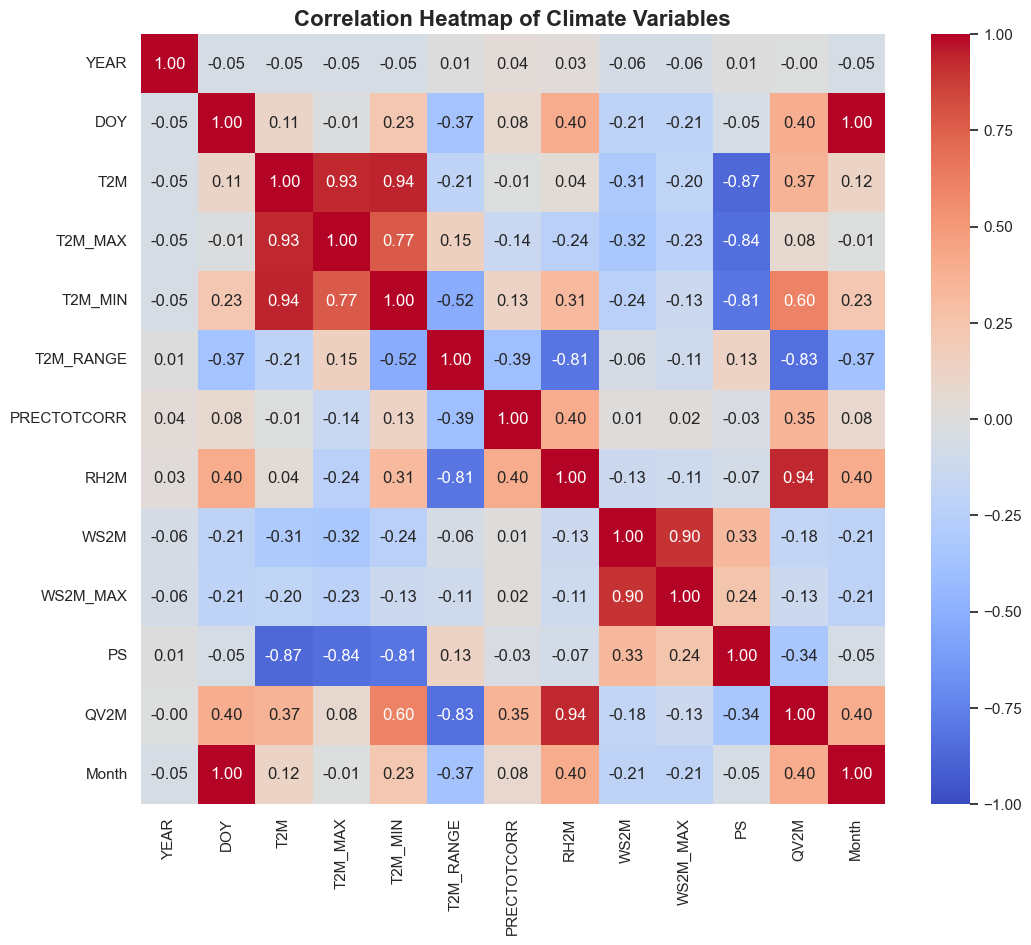

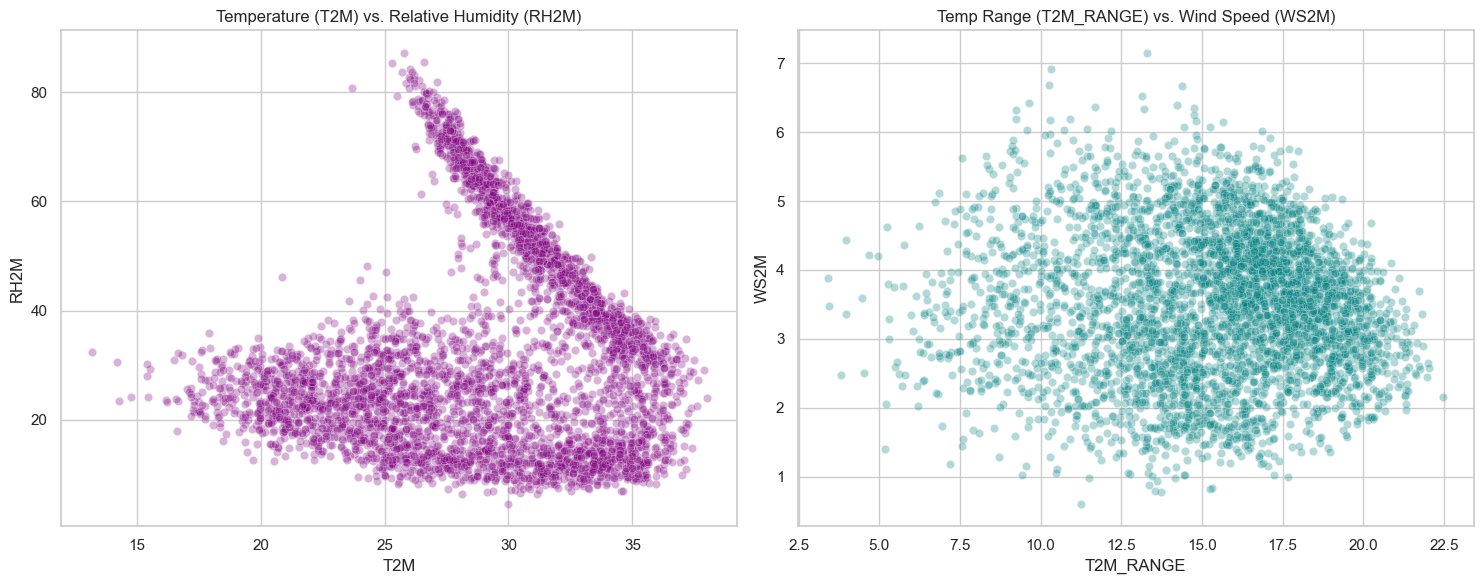


--- Top 3 Strongest Correlations ---
1. T2M and T2M_MIN = 0.942
2. RH2M and QV2M = 0.935
3. T2M and T2M_MAX = 0.934


In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Climate Variables", fontsize=16, fontweight='bold')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='T2M', y='RH2M', ax=ax1, alpha=0.3, color='purple')
ax1.set_title("Temperature (T2M) vs. Relative Humidity (RH2M)")

sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, alpha=0.3, color='teal')
ax2.set_title("Temp Range (T2M_RANGE) vs. Wind Speed (WS2M)")

plt.tight_layout()
plt.show()

corr_unstacked = corr_matrix.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 0.99].drop_duplicates().sort_values(ascending=False)

print("\n--- Top 3 Strongest Correlations ---")
for i, (vars_pair, val) in enumerate(corr_unstacked.head(3).items(), 1):
    real_val = corr_matrix.loc[vars_pair[0], vars_pair[1]]
    print(f"{i}. {vars_pair[0]} and {vars_pair[1]} = {real_val:.3f}")


### Correlation Interpretations

1. **Min Temp & Temperature (0.94):** `T2M_MIN` and `T2M` are strongly correlated. As the daily average temperature rises, the daily maximum temperature rises almost exactly in step. This indicates consistent diurnal heating patterns.
2. **Specific Humidity & Humidity (0.94):** `QV2M` and `RH2M` are strongly correlated. As the relative humidity increases, the actual mass of water vapor in the air (specific humidity) also increases. This is expected during the rainy season when the air is saturated.
3. **Max Temp & Temperature (0.93):** `T2M_MAX` and `T2M` are strongly correlated. As relative humidity increases (especially during the rainy season), the average temperature drops. This confirms our time-series observation that the rainiest months are also the coolest months due to cloud cover and evaporative cooling.


# Distribution Analysis

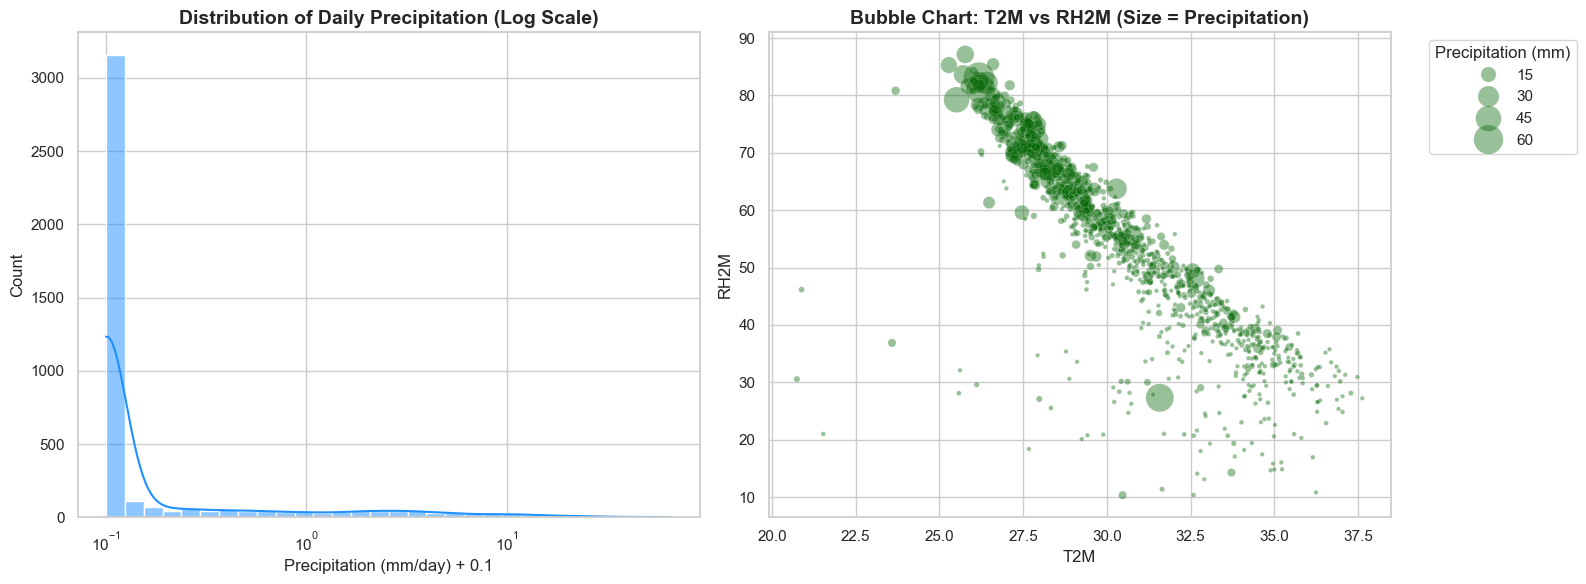

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['PRECTOTCORR'] + 0.1, bins=30, kde=True, log_scale=True, ax=ax1, color='dodgerblue')
ax1.set_title("Distribution of Daily Precipitation (Log Scale)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Precipitation (mm/day) + 0.1")

rainy_days = df[df['PRECTOTCORR'] > 0]
sns.scatterplot(data=rainy_days, x='T2M', y='RH2M', size='PRECTOTCORR', 
                sizes=(10, 500), alpha=0.4, color='darkgreen', ax=ax2)
ax2.set_title("Bubble Chart: T2M vs RH2M (Size = Precipitation)", fontsize=14, fontweight='bold')
ax2.legend(title="Precipitation (mm)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### Distribution Observations

* **Precipitation Histogram (Log Scale):** The precipitation data is heavily right-skewed. The vast majority of days have zero or very little rain. Applying a logarithmic scale reveals that while most non-zero rainfall is light, there is a distinct, long tail of rare but extreme heavy rainfall events.
* **Bubble Chart (T2M vs. RH2M by Rainfall Size):** The bubble chart confirms our earlier correlation: as relative humidity (`RH2M`) increases, average temperature (`T2M`) tends to drop. More importantly, the largest bubbles (representing the heaviest rain storms) are strongly clustered in the top-left region of the chart (high humidity, lower temperature). This confirms that extreme precipitation events strictly occur when the air mass is heavily saturated and temperatures have cooled.
